In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader 

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.ndimage import zoom

In [28]:
DEUTERONS = '/Users/user/data/research/proton-deuteron/csv/deuteron_candidates_induction.pkl'   # DEUTERON CANDIDATES CLUSTERS - INDUCTION PLANE
PROTONS = '/Users/user/data/research/proton-deuteron/csv/proton_candidates_induction.pkl'       # PROTON CANDIDATES CLUSTERS - INDUCTION PLANE

masses = pd.read_csv('/Users/user/data/research/proton-deuteron/csv/picky+match.csv')           # BEAMLINE INFO. 

deuterons = pd.read_pickle(DEUTERONS); 
protons = pd.read_pickle(PROTONS)

deuterons = pd.merge(
    deuterons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

protons = pd.merge(
    protons,
    masses[['run', 'subrun', 'event', 'p', 'm', 'beamline_mass']],
    on=['run', 'subrun', 'event'],
    how='left'
)

data = pd.concat([deuterons, protons], ignore_index=True)

In [12]:
protons.shape, deuterons.shape

((7448, 37), (6963, 37))

In [4]:
max(deuterons['width']), max(deuterons['height']), max(protons['width']), max(protons['height'])

(1354, 179, 1016, 179)

In [5]:
def pad_image(image, target_wh=(1354, 179)):
    """
    Place a 2D image block in the centre of a zero canvas.

    image: 2D np.ndarray, shape (h, w)
    target_wh: (target_width, target_height)
    """
    target_w, target_h = target_wh
    canvas = np.zeros((target_h, target_w), dtype=image.dtype)

    h, w = image.shape

    # Compute top-left corner so image is centred
    y0 = (target_h - h) // 2
    x0 = (target_w - w) // 2
    y1 = y0 + h
    x1 = x0 + w

    # Place the image block
    canvas[y0:y1, x0:x1] = image

    return canvas

In [8]:
def downsample_image(image, target_shape=(512, 40)):
    scale_y = target_shape[1] / image.shape[0]
    scale_x = target_shape[0] / image.shape[1]
    return zoom(image, (scale_y, scale_x), order=1)  # order=1 for bilinear interpolation

In [30]:
images = [] # all data

for idx, row in data.iterrows():
    padded = pad_image(
        row['image_intensity'])
    images.append(padded)

images = np.array(images)

downsampled = np.array([downsample_image(img, target_shape=(240, 240)) for img in images])

In [16]:
class CAE(nn.Module):
    def __init__(self, input_hw=(240, 240), latent=8):
        super(CAE, self).__init__()
        in_h, in_w = input_hw
        assert in_h % 16 == 0 and in_w % 16 == 0, "input spatial dims must be divisible by 16"

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 5, stride=2, padding=2), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 5, stride=2, padding=2), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 5, stride=2, padding=2), nn.BatchNorm2d(256), nn.ReLU()
        )

        self.h_enc = in_h // 16
        self.w_enc = in_w // 16
        flat_size = 256 * self.h_enc * self.w_enc

        self.fc_enc = nn.Linear(flat_size, latent)
        self.fc_dec = nn.Linear(latent, flat_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 5, stride=2, padding=2, output_padding=1),
            nn.ReLU()  
        )

    def forward(self, x):
        x = x.unsqueeze(1)               # (B,1,H,W)
        enc = self.encoder(x)            # (B,256,H_enc,W_enc)
        z = enc.view(enc.size(0), -1)    # (B, flat_size)
        z = self.fc_enc(z)               # (B, latent)
        z = self.fc_dec(z)               # (B, flat_size)
        y = z.view(x.size(0), 256, self.h_enc, self.w_enc)  # (B,256,H_enc,W_enc)
        y = self.decoder(y).squeeze(1)   # (B,H,W)
        return y

In [65]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CAE(input_hw=(240, 240), latent=16).to(device)
optim  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.MSELoss()

In [66]:
X = torch.tensor(downsampled, dtype=torch.float32).to(device)  # shape (N, H, W)
train_loader = torch.utils.data.DataLoader(X, batch_size=32, shuffle=True)
epochs = 15

In [67]:
for epoch in range(epochs):
    model.train()
    for xb in train_loader:
        xb = xb.to(device)
        optim.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, xb)
        loss.backward()
        optim.step()
    print(f"Epoch {epoch+1}: loss = {loss.item():.4f}")

Epoch 1: loss = 3.9026
Epoch 2: loss = 4.1629
Epoch 3: loss = 2.5394
Epoch 4: loss = 6.3218
Epoch 5: loss = 6.6055
Epoch 6: loss = 2.4302
Epoch 7: loss = 3.9905
Epoch 8: loss = 4.2587
Epoch 9: loss = 1.6884
Epoch 10: loss = 7.1779
Epoch 11: loss = 4.1792
Epoch 12: loss = 3.5036
Epoch 13: loss = 2.7723
Epoch 14: loss = 3.0063
Epoch 15: loss = 2.5772


In [ ]:
# import os
# os.makedirs("/Users/user/data/research/proton-deuteron/models", exist_ok=True)

# # Save checkpoint (best practice: save state_dict + optimizer + meta)
# save_path = "/Users/user/data/research/proton-deuteron/models/anomaly_checkpoint.pth"
# torch.save({
#     "epoch": epoch + 1,
#     "model_state_dict": model.state_dict(),
#     "optimizer_state_dict": optim.state_dict(),
#     "loss": loss.item()
# }, save_path)
# print("Saved checkpoint:", save_path)

# # Optional: save scripted model for inference (CPU-safe)
# scripted_path = "/Users/user/data/research/proton-deuteron/models/anomaly_scripted.pt"
# scripted = torch.jit.script(model.cpu())
# scripted.save(scripted_path)
# print("Saved scripted model:", scripted_path)

Saved checkpoint: /Users/user/data/research/proton-deuteron/models/anomaly_checkpoint.pth
Saved scripted model: /Users/user/data/research/proton-deuteron/models/anomaly_scripted.pt


In [47]:
ckpt = torch.load("/Users/user/data/research/proton-deuteron/models/anomaly_checkpoint.pth", map_location="cpu")
model = CAE(input_hw=(240,240), latent=8)
model.load_state_dict(ckpt["model_state_dict"])
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
optim.load_state_dict(ckpt["optimizer_state_dict"])
start_epoch = ckpt.get("epoch", 0)
model.to(device)  # move to desired device
print("Loaded checkpoint, resume at epoch", start_epoch)

Loaded checkpoint, resume at epoch 15


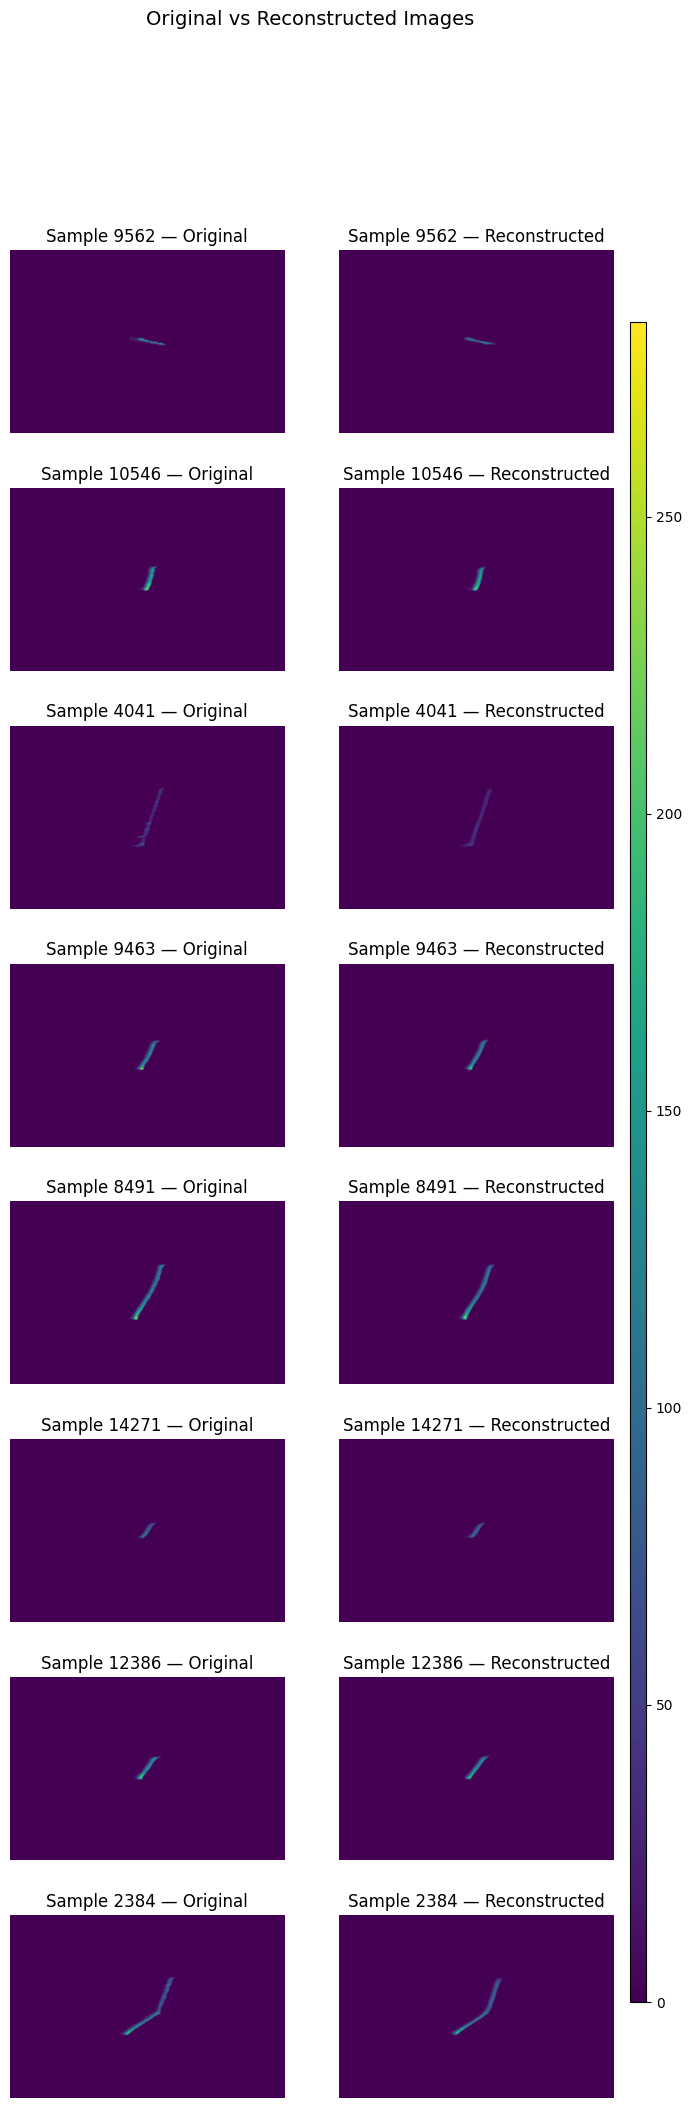

In [48]:
model.eval()

N = 8
X_cpu = X.detach().cpu().numpy()             # full dataset, shape (N_total, H, W)
sample_idx = np.random.choice(len(X_cpu), N, replace=False)
X_sample = X[sample_idx].to(device)          # tensor shape (N, H, W)

# Run through model
with torch.no_grad():
    recons = model(X_sample).cpu().numpy()   # (N, H, W)

# Original images
X_orig = X_sample.cpu().numpy()             # (N, H, W)

# common vmin/vmax for fair comparison
vmin = min(X_orig.min(), recons.min())
vmax = max(X_orig.max(), recons.max())

# Plot side-by-side original / reconstructed for each sample
fig, axes = plt.subplots(N, 2, figsize=(8, 3 * N))
if N == 1:
    axes = np.expand_dims(axes, 0)

for i in range(N):
    ax1 = axes[i, 0]
    ax2 = axes[i, 1]

    im1 = ax1.imshow(X_orig[i], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax1.set_title(f"Sample {sample_idx[i]} — Original")
    ax1.axis('off')

    im2 = ax2.imshow(recons[i], cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    ax2.set_title(f"Sample {sample_idx[i]} — Reconstructed")
    ax2.axis('off')

# add single colorbar on the right
fig.subplots_adjust(right=0.88, hspace=0.3)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im1, cax=cbar_ax)
plt.suptitle("Original vs Reconstructed Images", fontsize=14)
plt.show()

In [49]:
model.eval()

# choose inference device (fall back to CPU if MPS OOM issues persist)
device_inf = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Inference device:", device_inf)

# ensure model is on inference device
model.to(device_inf)

# operate on CPU numpy slices to control memory explicitly
X_np = X.detach().cpu().numpy()        # (N, H, W)
N, H, W = X_np.shape

batch_size = 8   # lower this if you hit MPS OOM
recon_all = np.empty((N, H, W), dtype=np.float32)

# prepare latent storage
latent_dim = model.fc_enc.out_features
latent_vectors = np.empty((N, latent_dim), dtype=np.float32)

with torch.no_grad():
    for i in range(0, N, batch_size):
        j = min(i + batch_size, N)
        xb_np = X_np[i:j]                                 # (b, H, W)
        xb = torch.tensor(xb_np, dtype=torch.float32).to(device_inf)

        # reconstruction
        out = model(xb)                                   # (b, H, W) on device_inf
        out_cpu = out.cpu().numpy()
        recon_all[i:j] = out_cpu

        # latent: run encoder (expects (B,1,H,W)), flatten and pass fc_enc
        enc = model.encoder(xb.unsqueeze(1))              # (b, C, h_enc, w_enc)
        z_flat = enc.flatten(1)                           # (b, flat_size)
        z = model.fc_enc(z_flat)                          # (b, latent)
        latent_vectors[i:j] = z.cpu().numpy()

        # free MPS cache if available
        if device_inf.type == "mps":
            try:
                torch.mps.empty_cache()
            except Exception:
                pass

# compute per-sample MSE (RE) on CPU
mse_per_pixel = (recon_all - X_np) ** 2
RE_per_sample = mse_per_pixel.mean(axis=(1, 2))        # (N,)

print("recon_all.shape:", recon_all.shape)
print("latent_vectors.shape:", latent_vectors.shape)
print("RE_per_sample.shape:", RE_per_sample.shape)

Inference device: mps
recon_all.shape: (14411, 240, 240)
latent_vectors.shape: (14411, 8)
RE_per_sample.shape: (14411,)


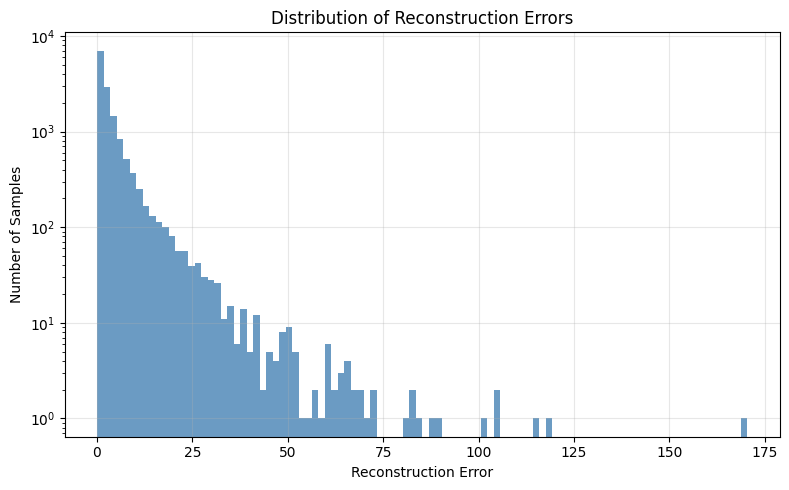

In [51]:
plt.figure(figsize=(8, 5))
plt.hist(RE_per_sample, bins=100, color='steelblue', alpha=0.8)
plt.xlabel("Reconstruction Error")
plt.ylabel("Number of Samples")
plt.title("Distribution of Reconstruction Errors")
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.show()

In [52]:
from sklearn.preprocessing import StandardScaler, normalize

Zs = StandardScaler().fit_transform(latent_vectors)              # Euclidean-friendly
Zc = normalize(latent_vectors, norm='l2')

In [55]:
from sklearn.mixture import GaussianMixture

lowest_bic, best = np.inf, None
for k in range(2, 4):
    for cov in ['full','tied','diag','spherical']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=0)
        gmm.fit(Zs)
        if gmm.bic(Zs) < lowest_bic:
            lowest_bic, best = gmm.bic(Zs), gmm
labels_gmm = best.predict(Zs)
soft = best.predict_proba(Zs)

/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/user/code/research/proton-deuteron/.venv/lib/python3.11/site-pac

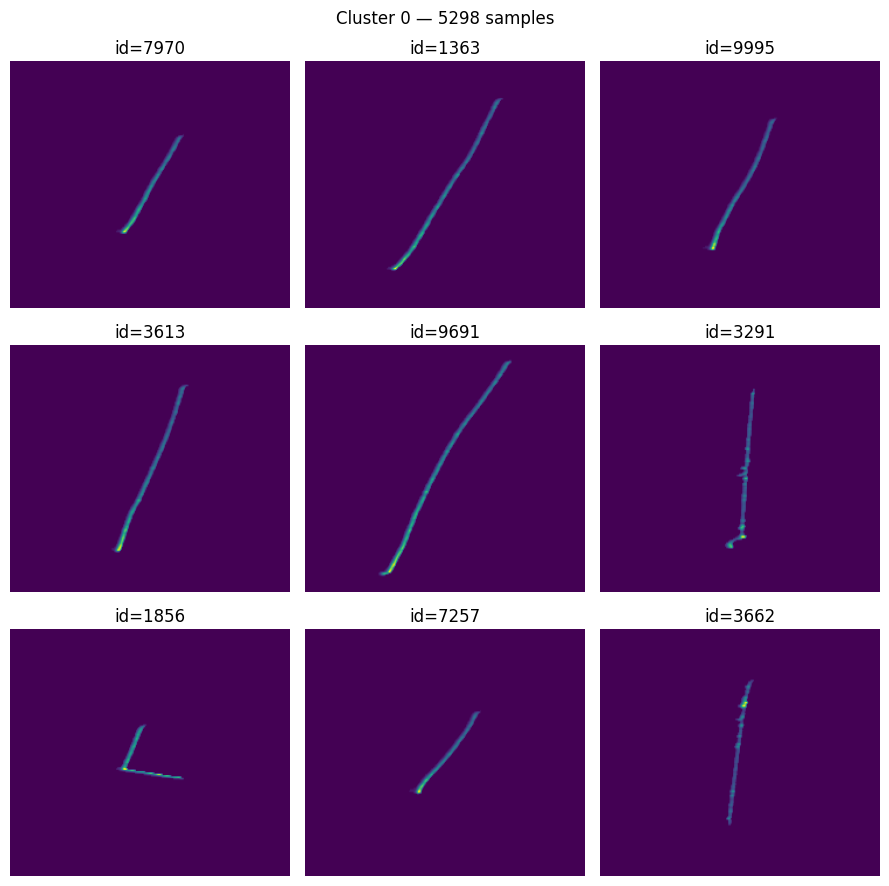

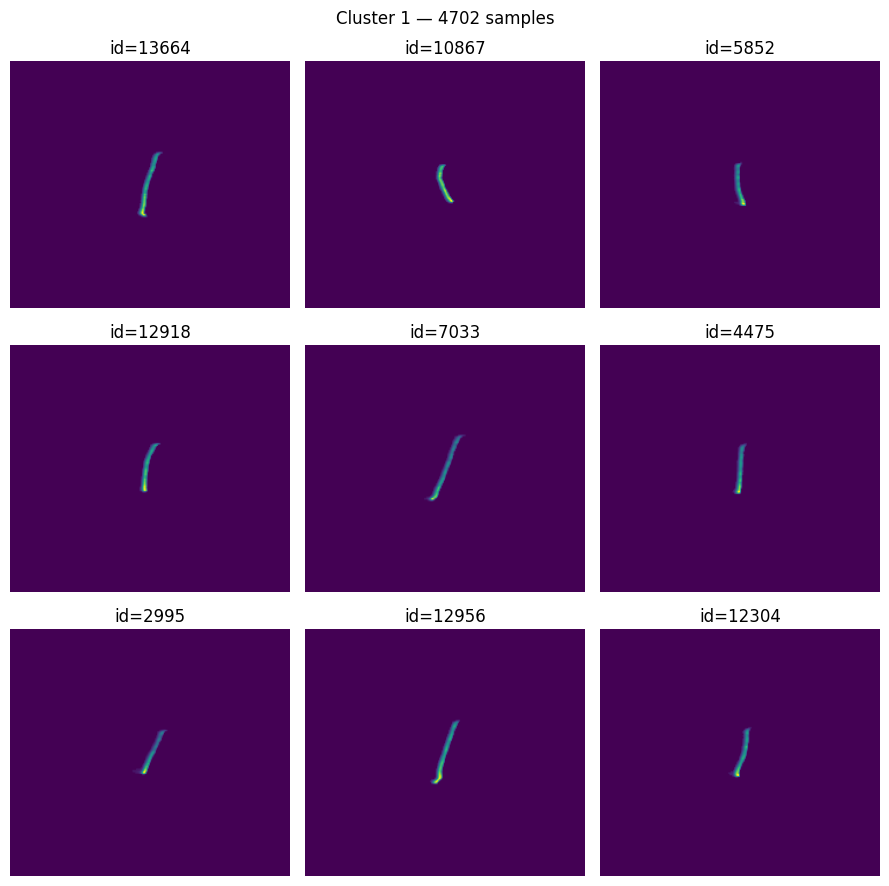

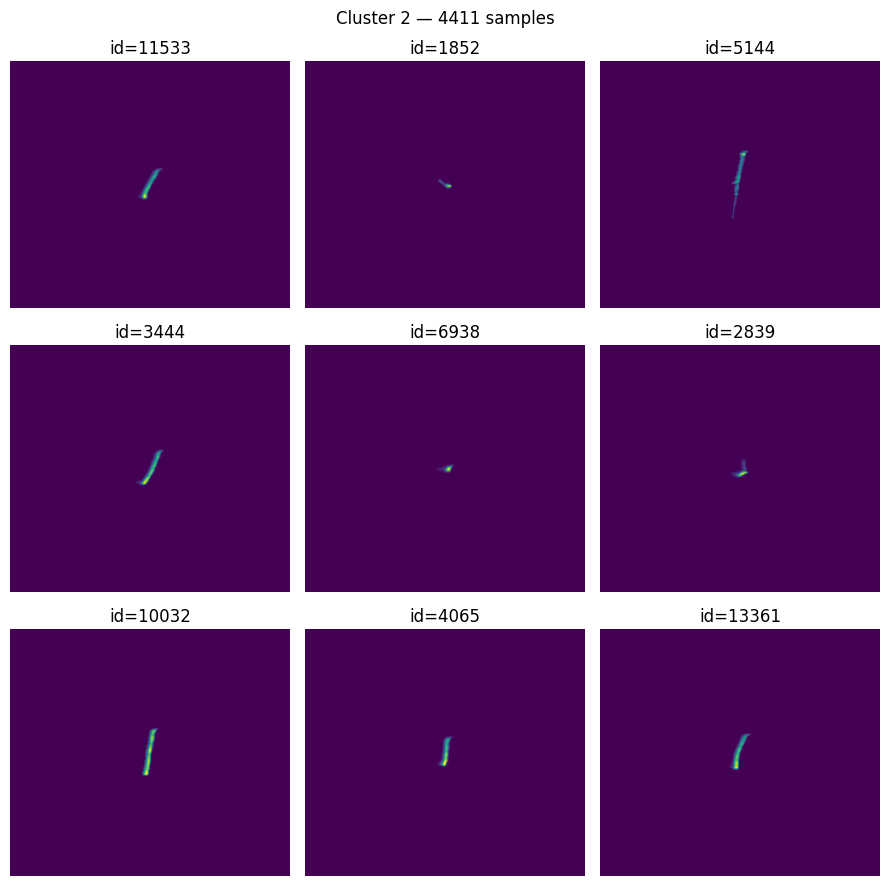

In [56]:
import math
unique_clusters = np.unique(labels_gmm)
for c in unique_clusters:
    idxs = np.where(labels_gmm == c)[0]
    if len(idxs) == 0:
        continue
    n_show = min(9, len(idxs))
    sel = np.random.choice(idxs, n_show, replace=False)
    cols = 3
    rows = math.ceil(n_show / cols)
    fig, axs = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axs = axs.ravel()
    for i, ax in enumerate(axs):
        if i < n_show:
            ax.imshow(X_np[sel[i]], cmap='viridis', aspect='auto')
            ax.set_title(f"id={sel[i]}")
        ax.axis('off')
    plt.suptitle(f'Cluster {c} — {len(idxs)} samples')
    plt.tight_layout()
    plt.show()

In [57]:
data['cluster_gmm'] = labels_gmm

<Axes: xlabel='maxdiff', ylabel='Count'>

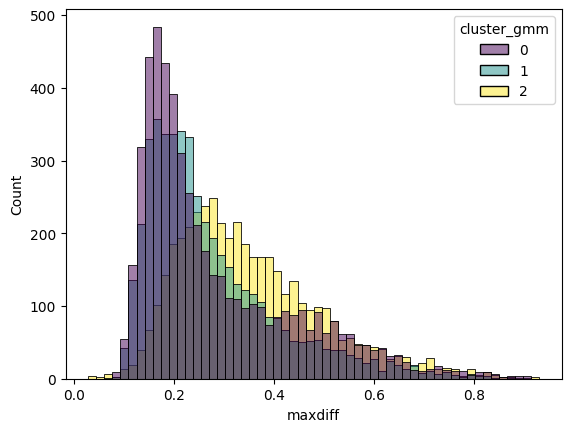

In [60]:
sns.histplot(data=data, x='maxdiff', hue='cluster_gmm', palette='viridis')

(600.0, 1500.0)

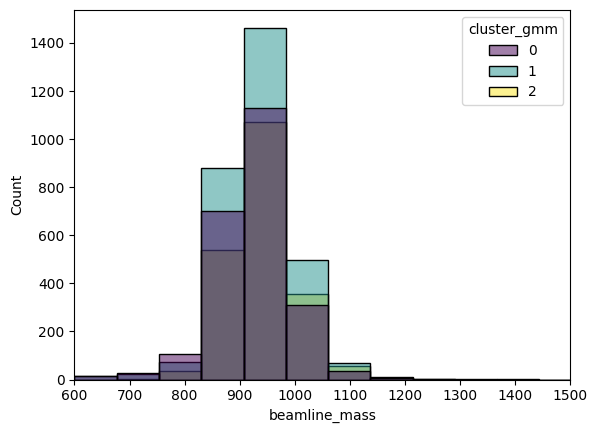

In [64]:
sns.histplot(data=data, x='beamline_mass', hue='cluster_gmm', palette='viridis')
plt.xlim(600, 1500)